In [1]:
# Allowing dynamic links, hot-reload, to our custom modules
%load_ext autoreload
%autoreload 2

In [2]:
import os

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [3]:
import os
import traceback

import matplotlib.pyplot as plt
import pandas as pd

os.getcwd()

'C:\\Beryllium Base\\WORKSPACES\\MTECH\\dl-gen-lyrics\\sandbox'

In [4]:
import generator_core as core
from aspect_red import *
from aspect_tetra import SolutionEvaluator

In [5]:
try:
    ds_subset = pd.read_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
    display(ds_subset.head())
except:
    traceback.print_exc()

,Unnamed: 0,title,tag,artist,year,lyrics,id,language
0,123725,In Memory of W. B. Yeats,misc,W. H. Auden,2013,I\n\nHe disappeared in the dead of winter:\nTh...,134446,en
1,2614099,Sthlm City,pop,Rebecca & Fiona,2018,"[Intro]\nI mean, like, it's okay\nOne day, you...",3931557,en
2,2550228,Fallin 2010,pop,Mozhdah,2010,[Verse 1]\nCan you take it easy\nWhile I make ...,3840000,en
3,3539706,Can the Circle Be Unbroken,country,Johnny Cash,1982,I was standing by the window\nOn one cold and ...,5350667,en
4,2650114,Marijuana,pop,Jah Cure,2019,[Intro: Jah Cure]\nOne puff one draw\nFrees th...,3982786,en


In [6]:
try:
    red = Red(ds_subset)
except:
    traceback.print_exc()

Loaded Cache for Midnight._prepare_ds_data.cached
Loaded Cache for Midnight._get_custom_tokens.cached
Loaded Cache for Midnight._get_genre_dict.cached
Loaded Cache for Midnight._prepare_tfidf.cached
Loaded Cache for Midnight._prepare_vocabulary temp\lyrics_sp.model
Loaded Cache for Midnight._prepare_embedder.cached


C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded Cache for Red._prepare_language_model.cached


In [9]:
try:
    train_language_model = True
    print(red.language_model)
    print(red.get_language_model_parameter_count())
except:
    traceback.print_exc()

EncoderDecoderLSTM(
  (embedding): Embedding(16000, 512, padding_idx=0)
  (encoder_lstm): LSTM(512, 512, num_layers=2, batch_first=True)
  (decoder_lstm): LSTM(512, 512, num_layers=2, batch_first=True)
  (fc): Linear(in_features=512, out_features=16000, bias=True)
)
16612992


In [7]:
try:
    if train_language_model:
        red.language_model.trainer.device = 'cuda'
        red.language_model.trainer.epochs = 1

        for pg in red.language_model.trainer.optimizer.param_groups:
            # pg['lr'] = 0.0001
            print(pg['lr'])

        # red.language_model.embedding.weight.requires_grad = True
        print(red.language_model.embedding.weight.requires_grad)

except:
    traceback.print_exc()

0.001
True


In [9]:
try:
    if train_language_model:
        red.language_model.train_model()
except:
    traceback.print_exc()

Epoch:  0/15    Train Loss: 9.67    TTS: 1.41    ETA: 828985.50
Epoch:  0/15    Train Loss: 6.85    TTS: 2.01    ETA: 69401.59
Epoch:  0/15    Train Loss: 5.41    TTS: 3.02    ETA: 39287.27
Epoch:  0/15    Train Loss: 6.77    TTS: 4.00    ETA: 32142.56
Epoch:  0/15    Train Loss: 5.60    Agg. Loss: 5.53    TTS: 5.01    ETA: 29038.57
Epoch:  0/15    Train Loss: 4.50    Agg. Loss: 5.17    TTS: 6.01    ETA: 27301.14
Epoch:  0/15    Train Loss: 5.13    Agg. Loss: 5.11    TTS: 7.01    ETA: 26173.16
Epoch:  0/15    Train Loss: 4.79    Agg. Loss: 5.01    TTS: 8.03    ETA: 25414.17
Epoch:  0/15    Train Loss: 3.49    Agg. Loss: 4.75    TTS: 9.03    ETA: 24827.29
Epoch:  0/15    Train Loss: 4.87    Agg. Loss: 4.50    TTS: 10.00    ETA: 24413.11
Epoch:  0/15    Train Loss: 3.03    Agg. Loss: 4.11    TTS: 11.00    ETA: 24047.94
Epoch:  0/15    Train Loss: 3.22    Agg. Loss: 3.82    TTS: 12.01    ETA: 23754.89
Epoch:  0/15    Train Loss: 3.64    Agg. Loss: 3.68    TTS: 13.02    ETA: 23535.27
Epoch

Traceback (most recent call last):
  File "C:\Users\mcxiv\AppData\Local\Temp\ipykernel_15976\2456067357.py", line 3, in <module>
    red.language_model.train_model()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\aspect_red\encoder_decoder.py", line 64, in train_model
    self.trainer.train()
    ~~~~~~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 191, in train
    self._train_step(epoch)
    ~~~~~~~~~~~~~~~~^^^^^^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 225, in _train_step
    loss.backward()
    ~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\_tensor.py", line 631, in backward
    torch.autograd.backward(
    ~~~~~~~~~~~~~~~~~~~~~~~^
        self, gradient, retain_graph, create_graph, inputs=inputs
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
  

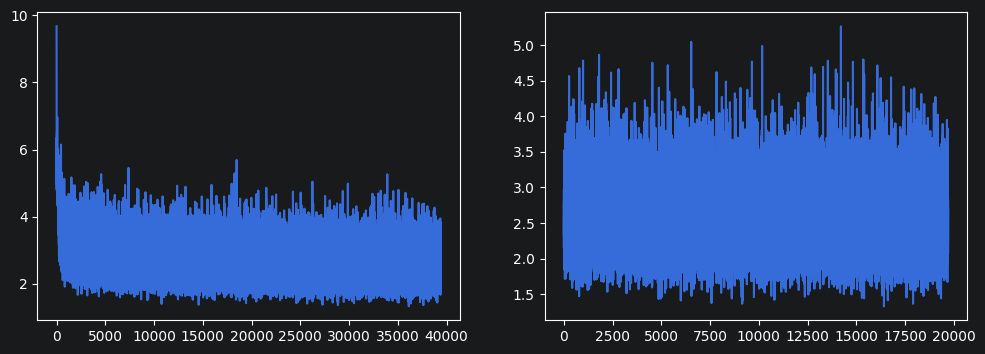

In [11]:
try:
    if train_language_model:
        loss = red.language_model.trainer.loss
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].plot(loss['train.batch'])
        axs[1].plot(loss['train.batch'][int(0.5 * len(loss['train.batch'])):])
        plt.show()
except:
    traceback.print_exc()

In [12]:
try:
    if train_language_model:
        timers = red.language_model.trainer.timer.timers
        for key in timers: print(key, timers[key].average)
except:
    traceback.print_exc()

train 0.0
_train_step 1409.9510470000005
train_dataloader 0.008506334449606237
batch 0.02757278071848698


In [13]:
try:
    if train_language_model:
        rewrite_language_model_cache = True
        if rewrite_language_model_cache:
            flight = 'Red._prepare_language_model.cached'
            for file in ['bone', 'pkl']:
                file = os.path.join('temp', f'{flight}.{file}')
                if os.path.exists(file): os.remove(file)
            core.key_cached('cached', lambda: red.language_model, group='Red._prepare_language_model')
            print("Saved")
except:
    traceback.print_exc()

Saved


In [11]:
try:
    print(red.inference('rock', 'black enter spell priests dragon', starting_words='', max_len=400))
except:
    traceback.print_exc()

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


['from so if if i was dead\nthen , i am a new man\nthey had a piece of heart\non a country world in the past with the light on the line\n" she\'re one thing from the house " )\ni didn " t mind on a gun - up and i need a song , she " s just a little more good , they have a friend or a long time\nbut girl , it is no money then\nin some day , she told me why she want her to be alright ?\n( there is a time to the sky )\n\nit\'s a diamond on the corner "\n" i read the beat of the game . " i\'m a ? ( one )\nwhat should i mean to run ? ) my ass ( i get a fuck ! ) \nand do you feel alright " hey )\n\noh baby please don\'t tell me how i need more and\nand i want a lot of shit and i " m the kid " i ain " t\nof my girls i\'m a )\nthat\'s got them money\nif she\'s']


In [40]:
try:
    _songs = red.bulk_inference(
        genres='rock',
        context_words='black enter spell priests dragon',
        max_len=500,
        temperature=1.0,
        top_k=20,
        n_songs=5,
    )
    for i, s in enumerate(_songs):
        print("SONG ", i + 1)
        print(s)
        print()
except:
    traceback.print_exc()

SONG  1
" let 'ert get a dream 
we " ll have to be there
and he says she " s a dog ?
he is her little
oh girl
he used to run
she can " t have a man
" yeah she was her always a lot with a good man he " s a man in your head
and she said " you can " t be " "
she don " t need a lil nigga ( yeah )
and you don' , i miss you . i " m a lot of the game on this shit . . . . . .
. . . . . . . .
i know you see yours ,
she know you want your head
but she is a few bands

that i'm the man to say ,
[ chorus i - d . na - na - na - na - na - na - na ) . . ( you and it )
he know how you get to ?
you ain " t got time to be
she " s an , " :
but that " s why it " s ( a bad man " d do you do your mind )

you a big friend i " m not
i know my baby
" what the fuck is " bout me - she

SONG  2
 - - - -
" this is my time "
a little good girl for the one you call me
they say you have the time to be so much more
and if i used to be at her i " ll be there , fuck you bitch
and when the nigga had a nigga in the club
so

In [7]:
import torch
from torch.nn.utils.rnn import pad_sequence
from generator_core import pad_lists

In [11]:
try:
    g, c, l = red.get_genre(1), " ".join(red.get_context_words(1)), red.get_lyrics(1)
    print(red.get_logits([(g, c, l)]).shape)
except:
    traceback.print_exc()

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


torch.Size([1, 816, 16000])


In [12]:
try:
    evaluator = SolutionEvaluator(red)
except:
    traceback.print_exc()

In [14]:
try:
    bertscore = evaluator.compute_bertscore(10)
    print(bertscore)
except:
    traceback.print_exc()

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6674.90it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  |

{'precision': np.float64(0.7167210578918457), 'recall': np.float64(0.6921448111534119), 'f1': np.float64(0.7039125561714172)}


In [ ]:
try:
    mauve = evaluator.compute_mauve()
    print(mauve)
except:
    traceback.print_exc()

In [16]:
try:
    perplexity = evaluator.compute_perplexity(collate=evaluator.default_collate)
    print(perplexity)
except:
    traceback.print_exc()

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


12.473528194427491


In [ ]:
try:
    self_bleu = evaluator.compute_self_bleu()
    print(self_bleu)
except:
    traceback.print_exc()

In [ ]:
try:
    print("Bert Score:")
    print(f" * Precision : {bertscore['precision']:.3f}")
    print(f" * Recall    : {bertscore['recall']:.3f}")
    print(f" * F1 Measure: {bertscore['f1']:.3f}")
    print(f"Mauve Score  : {mauve:.3f}")
    print(f"Perplexity   : {perplexity:.3f}")
    print(f"Self BLUE    : {self_bleu:.3f}")
except:
    traceback.print_exc()